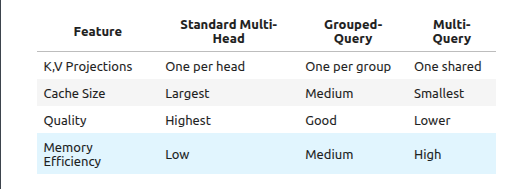


While MQA significantly reduces memory usage, it can sometimes degrade model quality. DeepSeek models use Grouped-Query Attention (GQA) as a balanced approach:

Group attention heads into clusters (e.g., 4-8 groups for 32 heads)
Each group shares the same K,V projections
Queries remain separate for each head
GQA offers a favorable trade-off:

Better quality than MQA (more expressive)
More efficient than standard multi-head attention
Well-suited for massive scale models

In [1]:
from torch._functorch._aot_autograd.logging_utils import model_name
import torch 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map = "auto"
)

/var/www/html/llm_scratch/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:05<00:00, 35.44it/s] 


=== GQA Configuration & Tensor Dimensions ===
Input Sequence Length          : 9 tokens
Raw Output Shape of k_proj     : torch.Size([1, 9, 256]) -> (batch_size, seq_len, kv_dim)
Number of Query (Q) Heads      : 32
Number of Key-Value (KV) Heads : 4
Dimension per Head (head_dim)  : 64
Group Size (Q-heads / KV-head) : 8

Reshaped K Tensor Shape        : torch.Size([1, 4, 9, 64]) -> (batch, num_kv_heads, seq_len, head_dim)
Expanded K Tensor Shape (for Q): torch.Size([1, 32, 9, 64]) -> (batch, num_q_heads, seq_len, head_dim)



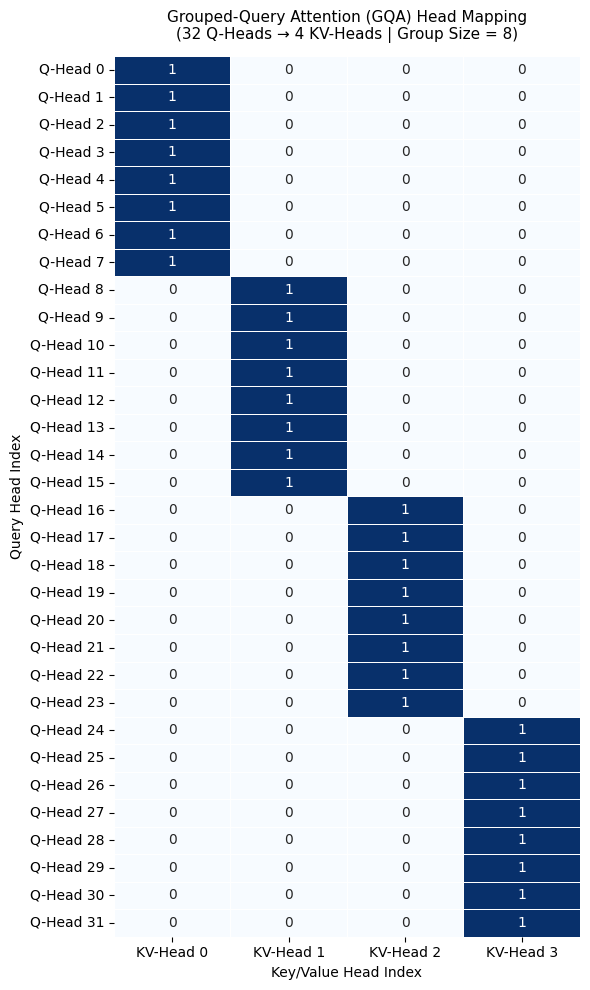

In [2]:
def visualize_gqa_mapping(input = "Hello, TinyLlama!", layer_idx = 0):
    inputs = tokenizer(input, return_tensors="pt").to(model.device)
    k_values = []
    def capture_hook(module, input, output):
        k_values.append(output.detach().cpu())

    layer = model.model.layers[layer_idx]
    k_hook = layer.self_attn.k_proj.register_forward_hook(capture_hook)

    with torch.no_grad():
        _ = model(**inputs)
    k_hook.remove()
    
    k = k_values[0]
    batch_size, seq_len, kv_dim = k.shape
    
    # 1. Extract GQA head configurations from model config
    num_q_heads = model.config.num_attention_heads
    num_kv_heads = getattr(model.config, "num_key_value_heads", num_q_heads)
    head_dim = kv_dim // num_kv_heads
    group_size = num_q_heads // num_kv_heads  # Number of Q-heads per KV-head
    
    print("=== GQA Configuration & Tensor Dimensions ===")
    print(f"Input Sequence Length          : {seq_len} tokens")
    print(f"Raw Output Shape of k_proj     : {k.shape} -> (batch_size, seq_len, kv_dim)")
    print(f"Number of Query (Q) Heads      : {num_q_heads}")
    print(f"Number of Key-Value (KV) Heads : {num_kv_heads}")
    print(f"Dimension per Head (head_dim)  : {head_dim}")
    print(f"Group Size (Q-heads / KV-head) : {group_size}\n")

    # 2. Reshape K tensor to split raw projection into distinct KV heads
    # Shape: (batch_size, seq_len, num_kv_heads, head_dim) -> (batch_size, num_kv_heads, seq_len, head_dim)
    k_reshaped = k.view(batch_size, seq_len, num_kv_heads, head_dim).transpose(1, 2)
    print(f"Reshaped K Tensor Shape        : {k_reshaped.shape} -> (batch, num_kv_heads, seq_len, head_dim)")

    # 3. Simulate Key expansion (repeat_interleave) used during attention computation
    # Each KV head is repeated `group_size` times along the head dimension (dim=1)
    k_expanded = k_reshaped.repeat_interleave(group_size, dim=1)
    print(f"Expanded K Tensor Shape (for Q): {k_expanded.shape} -> (batch, num_q_heads, seq_len, head_dim)\n")

    # 4. Construct Q-Head to KV-Head Mapping Matrix (shape: num_q_heads x num_kv_heads)
    mapping_matrix = np.zeros((num_q_heads, num_kv_heads))
    for q_idx in range(num_q_heads):
        kv_idx = q_idx // group_size
        mapping_matrix[q_idx, kv_idx] = 1

    # 5. Plot the mapping matrix as a heatmap
    plt.figure(figsize=(6, 10))
    sns.heatmap(
        mapping_matrix, 
        annot=True, 
        fmt=".0f", 
        cmap="Blues", 
        cbar=False,
        linewidths=0.5,
        yticklabels=[f"Q-Head {i}" for i in range(num_q_heads)],
        xticklabels=[f"KV-Head {j}" for j in range(num_kv_heads)]
    )
    plt.title(
        f"Grouped-Query Attention (GQA) Head Mapping\n"
        f"({num_q_heads} Q-Heads → {num_kv_heads} KV-Heads | Group Size = {group_size})", 
        fontsize=11, 
        pad=12
    )
    plt.xlabel("Key/Value Head Index", fontsize=10)
    plt.ylabel("Query Head Index", fontsize=10)
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_gqa_mapping()
